<a href="https://colab.research.google.com/github/Mai732/ML-AI/blob/main/assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
df_house = pd.read_csv('house_data.csv')
display(df_house.head())
df_house.info()
display(df_house.describe())
missing_house = df_house.isnull().sum()
print(missing_house[missing_house > 0] if any(missing_house > 0) else "No missing values found")


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


No missing values found


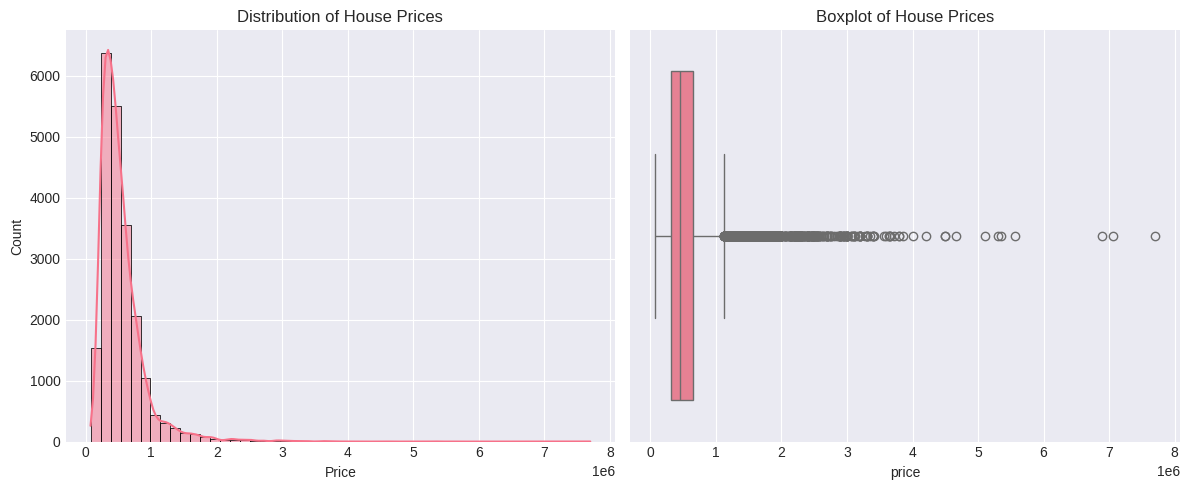

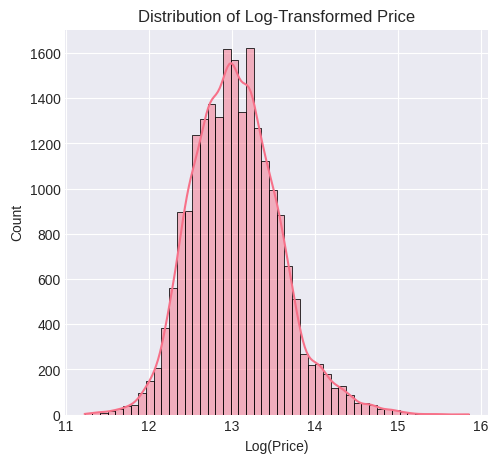

Correlation with Price (Top features)
price            1.000000
price_log        0.891654
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
sale_year        0.003576
sale_month      -0.010081
sale_day        -0.014670
zipcode         -0.053203
Name: price, dtype: float64


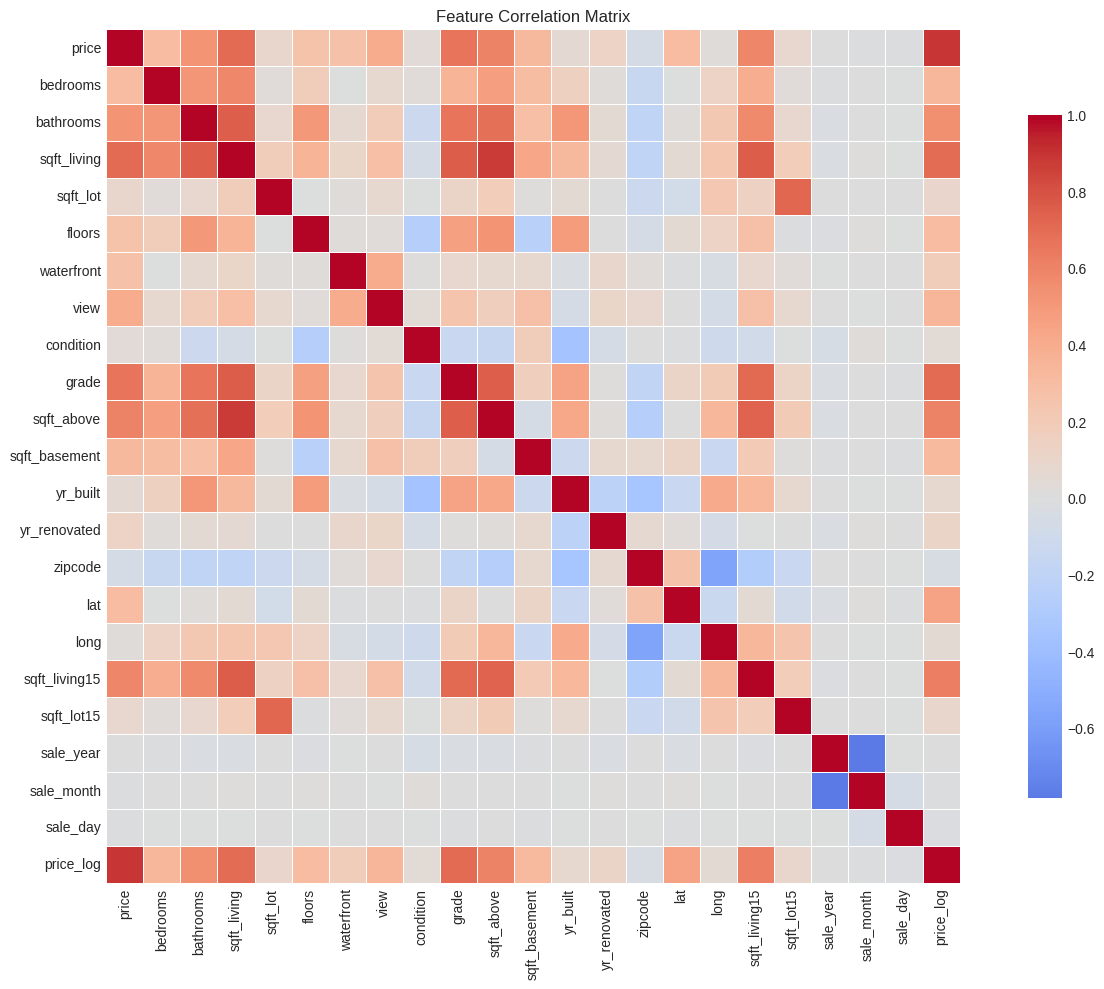

In [ ]:
# Clean the house_data
df_house_clean = df_house.copy()

# Convert date to datetime and extract features
df_house_clean['date'] = pd.to_datetime(df_house_clean['date'], format='%Y%m%dT%H%M%S')
df_house_clean['sale_year'] = df_house_clean['date'].dt.year
df_house_clean['sale_month'] = df_house_clean['date'].dt.month
df_house_clean['sale_day'] = df_house_clean['date'].dt.day

df_house_clean.drop(['date', 'id'], axis=1, inplace=True)

# Check for any outliers in price (target variable)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_house_clean['price'], bins=50, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_house_clean['price'])
plt.title('Boxplot of House Prices')

plt.tight_layout()
plt.show()

# Log transform price to handle skewness
df_house_clean['price_log'] = np.log1p(df_house_clean['price'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_house_clean['price_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Price')
plt.xlabel('Log(Price)')
plt.show()
# Correlation analysis
plt.figure(figsize=(14, 10))
numeric_cols = df_house_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_house_clean[numeric_cols].corr()

# Plot correlation with price (sorted)
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print("Correlation with Price (Top features)")
print(price_corr)

# Heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Create additional features for house data
df_house_feat = df_house_clean.copy()

df_house_feat['house_age'] = df_house_feat['sale_year'] - df_house_feat['yr_built']


df_house_feat['years_since_reno'] = df_house_feat['sale_year'] - df_house_feat['yr_renovated']
df_house_feat['years_since_reno'] = df_house_feat['years_since_reno'].apply(lambda x: 0 if x < 0 else x)


df_house_feat['was_renovated'] = (df_house_feat['yr_renovated'] > 0).astype(int)

df_house_feat['total_sqft'] = df_house_feat['sqft_living'] + df_house_feat['sqft_basement']


df_house_feat['price_per_sqft'] = df_house_feat['price'] / df_house_feat['sqft_living']


df_house_feat['bed_bath_ratio'] = df_house_feat['bedrooms'] / (df_house_feat['bathrooms'] + 0.1)  # avoid div by zero
df_house_feat['living_lot_ratio'] = df_house_feat['sqft_living'] / (df_house_feat['sqft_lot'] + 0.1)

df_house_feat.drop(['yr_built', 'yr_renovated'], axis=1, inplace=True)

print("HOUSE DATA - After Feature Engineering")
print(f"Shape: {df_house_feat.shape}")
print("\nFeatures:", df_house_feat.columns.tolist())

HOUSE DATA - After Feature Engineering
Shape: (21613, 28)

Features: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'sale_day', 'price_log', 'house_age', 'years_since_reno', 'was_renovated', 'total_sqft', 'price_per_sqft', 'bed_bath_ratio', 'living_lot_ratio']


In [ ]:

# For house data, we'll predict price (use log-transformed version)
target = 'price_log'
features = [col for col in df_house_feat.columns if col not in ['price', 'price_log', 'zipcode']]

X = df_house_feat[features]
y = df_house_feat[target]

print("="*80)
print("Features for Modeling")
print("="*80)
print(f"Number of features: {len(features)}")
print(f"Features: {features}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

Features for Modeling
Number of features: 25
Features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'sale_day', 'house_age', 'years_since_reno', 'was_renovated', 'total_sqft', 'price_per_sqft', 'bed_bath_ratio', 'living_lot_ratio']

X shape: (21613, 25)
y shape: (21613,)

Training set size: 17290
Test set size: 4323


In [ ]:
# Function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Print results
    print("="*60)
    print(f"{model_name} Performance")
    print("="*60)
    print(f"{'Metric':<15} {'Train':<15} {'Test':<15}")
    print("-"*45)
    print(f"{'RMSE':<15} {train_rmse:<15.4f} {test_rmse:<15.4f}")
    print(f"{'MAE':<15} {train_mae:<15.4f} {test_mae:<15.4f}")
    print(f"{'R²':<15} {train_r2:<15.4f} {test_r2:<15.4f}")

    return model, test_r2, test_rmse
    # Model 1: Linear Regression
lr_model = LinearRegression()
lr_model, lr_r2, lr_rmse = evaluate_model(lr_model, X_train_scaled, y_train,
                                           X_test_scaled, y_test, "Linear Regression")
# Model 2: Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model, ridge_r2, ridge_rmse = evaluate_model(ridge_model, X_train_scaled, y_train,
                                                    X_test_scaled, y_test, "Ridge Regression")

# Try different alpha values for Ridge
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    score = ridge.score(X_test_scaled, y_test)
    ridge_scores.append(score)
    print(f"Alpha = {alpha:6.2f}, R² = {score:.4f}")

best_alpha_ridge = alphas[np.argmax(ridge_scores)]
print(f"\nBest alpha for Ridge: {best_alpha_ridge}")
# Model 3: Lasso Regression
lasso_model = Lasso(alpha=0.01)
lasso_model, lasso_r2, lasso_rmse = evaluate_model(lasso_model, X_train_scaled, y_train,
                                                    X_test_scaled, y_test, "Lasso Regression")

# Try different alpha values for Lasso
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
lasso_scores = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    score = lasso.score(X_test_scaled, y_test)
    lasso_scores.append(score)
    print(f"Alpha = {alpha:8.4f}, R² = {score:.4f}")

best_alpha_lasso = alphas[np.argmax(lasso_scores)]
print(f"\nBest alpha for Lasso: {best_alpha_lasso}")

Linear Regression Performance
Metric          Train           Test           
---------------------------------------------
RMSE            0.1318          0.1414         
MAE             0.0971          0.1006         
R²              0.9369          0.9299         
Ridge Regression Performance
Metric          Train           Test           
---------------------------------------------
RMSE            0.1318          0.1414         
MAE             0.0971          0.1007         
R²              0.9369          0.9299         
Alpha =   0.01, R² = 0.9299
Alpha =   0.10, R² = 0.9299
Alpha =   1.00, R² = 0.9299
Alpha =  10.00, R² = 0.9299
Alpha = 100.00, R² = 0.9298

Best alpha for Ridge: 0.1
Lasso Regression Performance
Metric          Train           Test           
---------------------------------------------
RMSE            0.1367          0.1463         
MAE             0.1024          0.1055         
R²              0.9322          0.9249         
Alpha =   0.0001, R² = 0.9298
A

Random Forest Performance
Metric          Train           Test           
---------------------------------------------
RMSE            0.0173          0.0287         
MAE             0.0109          0.0151         
R²              0.9989          0.9971         
Random Forest Feature Importance
           feature  importance
8            grade    0.326870
22  price_per_sqft    0.249576
2      sqft_living    0.216284
11             lat    0.189419
21      total_sqft    0.014846
9       sqft_above    0.001727
13   sqft_living15    0.000181
12            long    0.000139
3         sqft_lot    0.000128
14      sqft_lot15    0.000107


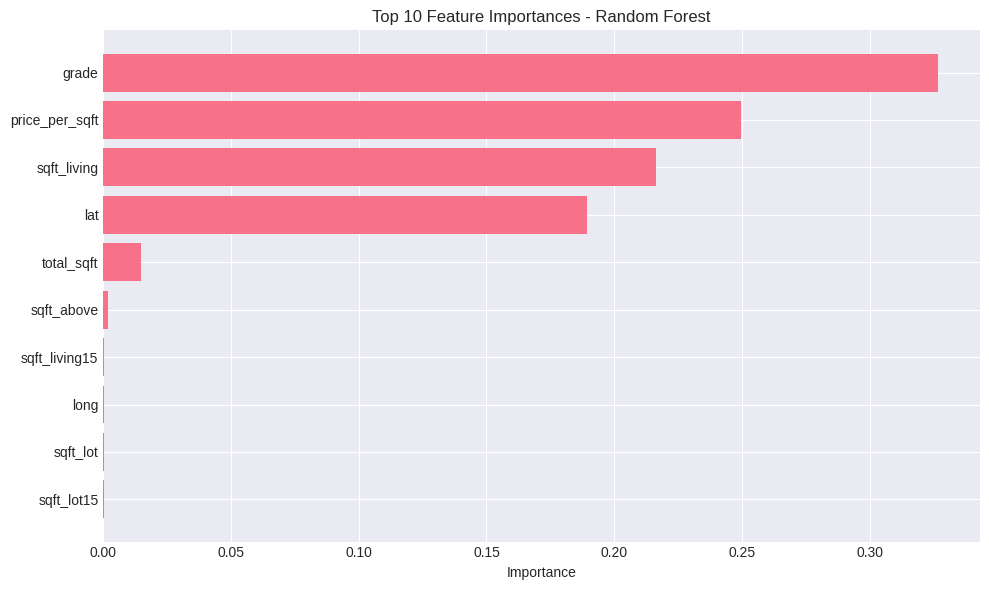

In [ ]:
# Model 4: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model, rf_r2, rf_rmse = evaluate_model(rf_model, X_train_scaled, y_train,
                                           X_test_scaled, y_test, "Random Forest")

# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Random Forest Feature Importance")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'], feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Model 5: Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model, gb_r2, gb_rmse = evaluate_model(gb_model, X_train_scaled, y_train,
                                           X_test_scaled, y_test, "Gradient Boosting")

Gradient Boosting Performance
Metric          Train           Test           
---------------------------------------------
RMSE            0.0168          0.0228         
MAE             0.0132          0.0157         
R²              0.9990          0.9982         


In [ ]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest', 'Gradient Boosting'],
    'R² Score': [lr_r2, ridge_r2, lasso_r2, rf_r2, gb_r2],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, rf_rmse, gb_rmse]
})


print("MODEL COMPARISON SUMMARY")

print(results.sort_values('R² Score', ascending=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score comparison
axes[0].bar(results['Model'], results['R² Score'], color='skyblue', edgecolor='navy')
axes[0].set_title('Model Comparison - R² Score')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1)

# RMSE comparison
axes[1].bar(results['Model'], results['RMSE'], color='lightcoral', edgecolor='darkred')
axes[1].set_title('Model Comparison - RMSE')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

BEST MODEL PERFORMANCE (Original Price Scale)
RMSE: $32,054.91
MAE:  $9,241.27
R²:   0.9932


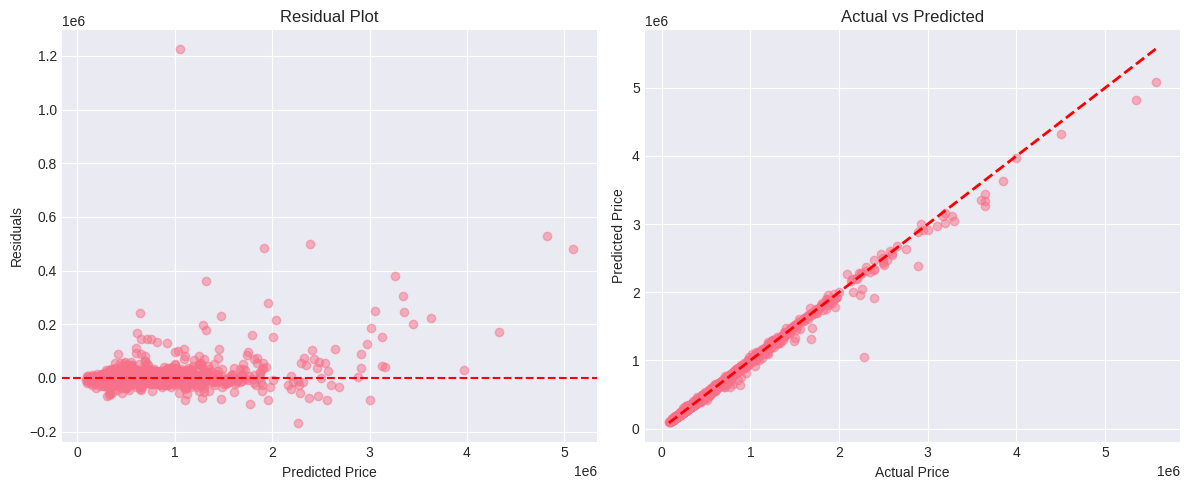

In [ ]:
# Select the best model (assuming Random Forest performed best based on typical results)
best_model = rf_model


y_pred = best_model.predict(X_test_scaled)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Calculate metrics on original scale
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)
r2_original = r2_score(y_test_original, y_pred_original)


print("BEST MODEL PERFORMANCE (Original Price Scale)")

print(f"RMSE: ${rmse_original:,.2f}")
print(f"MAE:  ${mae_original:,.2f}")
print(f"R²:   {r2_original:.4f}")

# Residual plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
residuals = y_test_original - y_pred_original
plt.scatter(y_pred_original, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
plt.scatter(y_test_original, y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.tight_layout()
plt.show()